## **Image Classification using `sklearn.svm`**
Image files used are from https://github.com/Abhishek-Arora/Image-Classification-Using-SVM


### Comparing Random Forest and SVM for Image Classification

**The main goal is to build a model that can accurately classify images into different categories.**

The notebook covers the following tasks:

1. **Loading and Preprocessing Image Data:** Images are loaded from a structured directory and preprocessed to a consistent size.
2. **Splitting Data into Training and Testing Sets:** The dataset is split to evaluate the model's performance on unseen data.
3. **Training a Random Forest Classifier with Parameter Optimization:** A Random Forest classifier is trained, and GridSearchCV is used to optimize hyperparameters such as n_estimators, max_depth, min_samples_split, and min_samples_leaf.
4. **Making Predictions:** The best Random Forest model is used to predict the classes of images in the testing dataset.
5. **Evaluating Model Performance:** Model performance is evaluated using accuracy, precision, recall, F1-score, a classification report, and a confusion matrix.

In [ ]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Import libraries 
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

from sklearn import svm, metrics
from sklearn.utils import Bunch
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from skimage.io import imread
from skimage.transform import resize

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

%matplotlib inline

### **1. Load and Preprocess the images**

In [11]:
# Current folder containing the five image categories
image_folder = "."

categories = [
    "dalmatian",
    "dollar_bill",
    "pizza",
    "soccer_ball",
    "sunflower"]

# Uniform image size
image_size = (64, 64)

data = []
labels = []

for category in categories:
    category_path = os.path.join(image_folder, category)

    for image_file in os.listdir(category_path):
        image_path = os.path.join(category_path, image_file)

        try:
            # 1. Load image
            image = imread(image_path)

            # 2. Resize image to 64 x 64
            image = resize(image, image_size)

            # 3. Normalize and flatten image
            image = image.flatten()

            data.append(image)
            labels.append(category)

        except Exception as e:
            print(f"Could not process {image_path}: {e}")

X = np.array(data)
y = np.array(labels)

print("Number of images:", len(X))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of images: 309
X shape: (309, 12288)
y shape: (309,)


In [12]:
# Split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("Training images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Training images: 247
Testing images: 62
X_train shape: (247, 12288)
X_test shape: (62, 12288)


### **2. Model training**

In [14]:
# Define the parameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [15]:
# Create the Random Forest classifier

rf = RandomForestClassifier(
    random_state=42)

In [16]:
# Perform GridSearchCV

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1)

In [18]:
# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exam

In [19]:
# Print the best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [20]:
# Best cross-validation score
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.2%}")

Best Cross-Validation Accuracy: 78.98%


In [21]:
# Get the best Random Forest model
best_rf = grid_search.best_estimator_

print("Best Random Forest Model:")
print(best_rf)

Best Random Forest Model:
RandomForestClassifier(n_estimators=200, random_state=42)


### **3. Model Evaluation**

In [22]:
# Make predictions on the test data
y_pred = best_rf.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [24]:
# Calculate accuracy, precision, recall, and F1-score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1:.2%}")

Accuracy:  77.42%
Precision: 79.03%
Recall:    77.42%
F1-score:  77.09%


In [25]:
# Create the classification report
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

   dalmatian       0.68      0.93      0.79        14
 dollar_bill       0.75      0.60      0.67        10
       pizza       0.75      0.60      0.67        10
 soccer_ball       1.00      0.73      0.84        11
   sunflower       0.79      0.88      0.83        17

    accuracy                           0.77        62
   macro avg       0.79      0.75      0.76        62
weighted avg       0.79      0.77      0.77        62



In [26]:
# Create a confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=categories
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[13  1  0  0  0]
 [ 2  6  1  0  1]
 [ 1  0  6  0  3]
 [ 2  1  0  8  0]
 [ 1  0  1  0 15]]


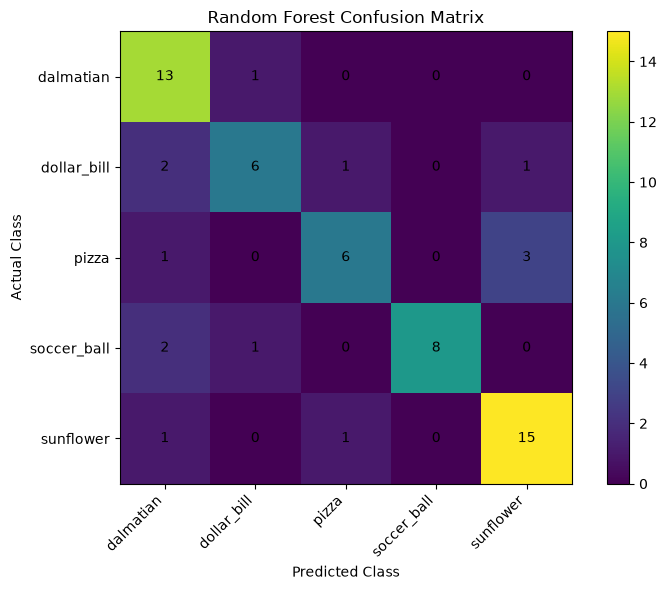

In [27]:
# Visualize the confusion matrix with Matplotlib

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm)

ax.set_xticks(np.arange(len(categories)))
ax.set_yticks(np.arange(len(categories)))

ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_yticklabels(categories)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_title("Random Forest Confusion Matrix")

# Display the numbers inside the matrix
for i in range(len(categories)):
    for j in range(len(categories)):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im)
plt.tight_layout()
plt.show()

In [17]:
# Print the best parameters

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:


AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

### Load images in structured directory like it's sklearn sample dataset

In [4]:
def load_image_files(container_path, dimension=(64, 64)):
    """
    Load image files with categories as subfolder names
    which performs like scikit-learn sample dataset

    Parameters
    ----------
    container_path : string or unicode
        Path to the main folder holding one subfolder per category
    dimension : tuple
        size to which image are adjusted to

    Returns
    -------
    Bunch
    """
    image_dir = Path(container_path)
    folders = [directory for directory in image_dir.iterdir() if directory.is_dir()]
    categories = [fo.name for fo in folders]

    descr = "A image classification dataset"
    images = []
    flat_data = []
    target = []
    for i, direc in enumerate(folders):
        for file in direc.iterdir():
            img = skimage.io.imread(file)
            img_resized = resize(img, dimension, anti_aliasing=True, mode='reflect')
            flat_data.append(img_resized.flatten())
            images.append(img_resized)
            target.append(i)
    flat_data = np.array(flat_data)
    target = np.array(target)
    images = np.array(images)

    return Bunch(data=flat_data,
                 target=target,
                 target_names=categories,
                 images=images,
                 DESCR=descr)

In [5]:
# Update the path to where your images are located
image_dataset = load_image_files("/content/Image-Classification-Using-SVM/images/")

### Split data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    image_dataset.data, image_dataset.target, test_size=0.3,random_state=109)

### Train data with parameter optimization

In [7]:
param_grid = [
  {'C': [1, 10, 100, 1000], 'kernel': ['linear']},
  {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
 ]
svc = svm.SVC()
clf = GridSearchCV(svc, param_grid)
clf.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']}])

### Predict

In [8]:
y_pred = clf.predict(X_test)

### Report

In [9]:
print("Classification report for - \n{}:\n{}\n".format(
    clf, metrics.classification_report(y_test, y_pred)))

Classification report for - 
GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']}]):
              precision    recall  f1-score   support

           0       0.68      0.77      0.72        22
           1       0.86      0.96      0.91        26
           2       0.90      0.60      0.72        15
           3       0.57      0.53      0.55        15
           4       0.80      0.80      0.80        15

    accuracy                           0.76        93
   macro avg       0.76      0.73      0.74        93
weighted avg       0.77      0.76      0.76        93


